# $ \text{Т.13} $

$ \text{Исследование длины и ширины 139 черепов,} \\ \text{ найденных в Верхнем Египте и относимых к расе,} \\ \text{ жившей за 8000 лет до нашей эры, показало,} \\ \text{ что стандартное отклонение длины и ширины черепа} \\ \text{ 5.722 и 4.612 мм соответственно. Те же величины,} \\ \text{ выведенные на основании обследования 1000 европейцев,} \\ \text{ оказались равными 6.161 и 5.055 мм.} $

### $$ \alpha = 0.05 $$

In [18]:
import scipy.stats as stats

import numpy as np
import matplotlib.pyplot as plot
from matplotlib.ticker import AutoMinorLocator


In [19]:
alpha = 0.05
n = 139
m = 1000

## $ \text{0) Предполагая, что законы распределения длины и ширины черепа нормальные,} \\ \text{ выяснить, можно ли считать расхождения стандартов случайными.} $

In [20]:
quantile_alpha_2 = stats.f.ppf(alpha / 2, n - 1, m - 1)

print(f"Квантиль распределения Фишера порядка α/2 = {quantile_alpha_2:.6f}")
print(f"(степени свободы: {n-1}, {m-1})")

Квантиль распределения Фишера порядка α/2 = 0.767382
(степени свободы: 138, 999)


In [21]:
quantile_1_minus_alpha_2 = stats.f.ppf(1 - alpha / 2, n - 1, m - 1)

print(f"Квантиль распределения Фишера порядка 1 - α/2 = {quantile_1_minus_alpha_2:.6f}")
print(f"(степени свободы: {n-1}, {m-1})")

Квантиль распределения Фишера порядка 1 - α/2 = 1.271697
(степени свободы: 138, 999)


In [22]:
Sx_length, Sy_length = 5.722, 6.161
Sx_width, Sy_width = 4.612, 5.055

In [23]:
delta_length = Sx_length ** 2 / Sy_length ** 2

print("=" * 40)
print("Значение delta для длины")
print(delta_length)
print("=" * 40)

Значение delta для длины
0.8625678945904338


In [24]:
delta_width = Sx_width ** 2 / Sy_width ** 2

print("=" * 40)
print("Значение delta для ширины")
print(delta_width)
print("=" * 40)

Значение delta для ширины
0.8324080612765026


#### $ \text{Во всех случаях (и по длине, и по ширине черепа)} \\ \text{не достаточно оснований отвергнуть гипотезу о равенстве дисперсий.} $


## $ \text{1) Построить график мощности критерия.} $

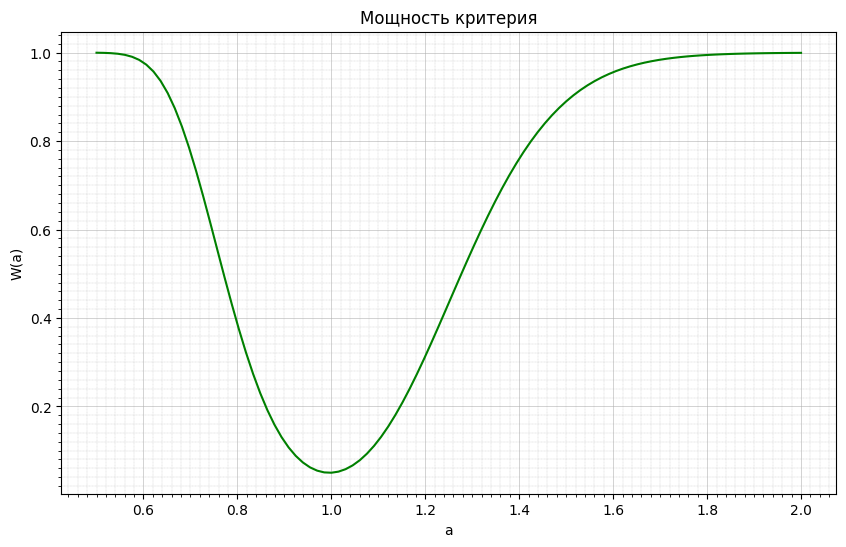

In [25]:
_, axs = plot.subplots(1, 1, figsize=(10, 6))

axs.set_title("Мощность критерия")
axs.set_xlabel("a")
axs.set_ylabel("W(a)")

a = np.linspace(0.5, 2, 100)

axs.plot(a, 1 - stats.f.cdf(quantile_1_minus_alpha_2, n - 1, m - 1, scale=a) +
         stats.f.cdf(quantile_alpha_2, n - 1, m - 1, scale=a), color="green")

axs.xaxis.set_minor_locator(AutoMinorLocator(10))
axs.yaxis.set_minor_locator(AutoMinorLocator(10))

plot.grid(which='minor', linestyle='--', linewidth=0.2)
plot.grid(which='major', linewidth=0.4)

plot.show()